# 🚕 Real-Time Ride-Booking Data Pipeline

**Azure Event Hubs · Databricks · Spark Declarative Pipelines · Azure Data Factory · Jinja2 SQL Templating**

An end-to-end real-time data engineering pipeline for a ride-booking platform, built using the modern Azure/Databricks stack. The system captures live ride-booking events via streaming, enriches them with contextual reference data, and delivers a fully modelled star schema - all with a metadata-driven architecture that requires zero code changes when new data sources are added.

---

## 📐 Architecture
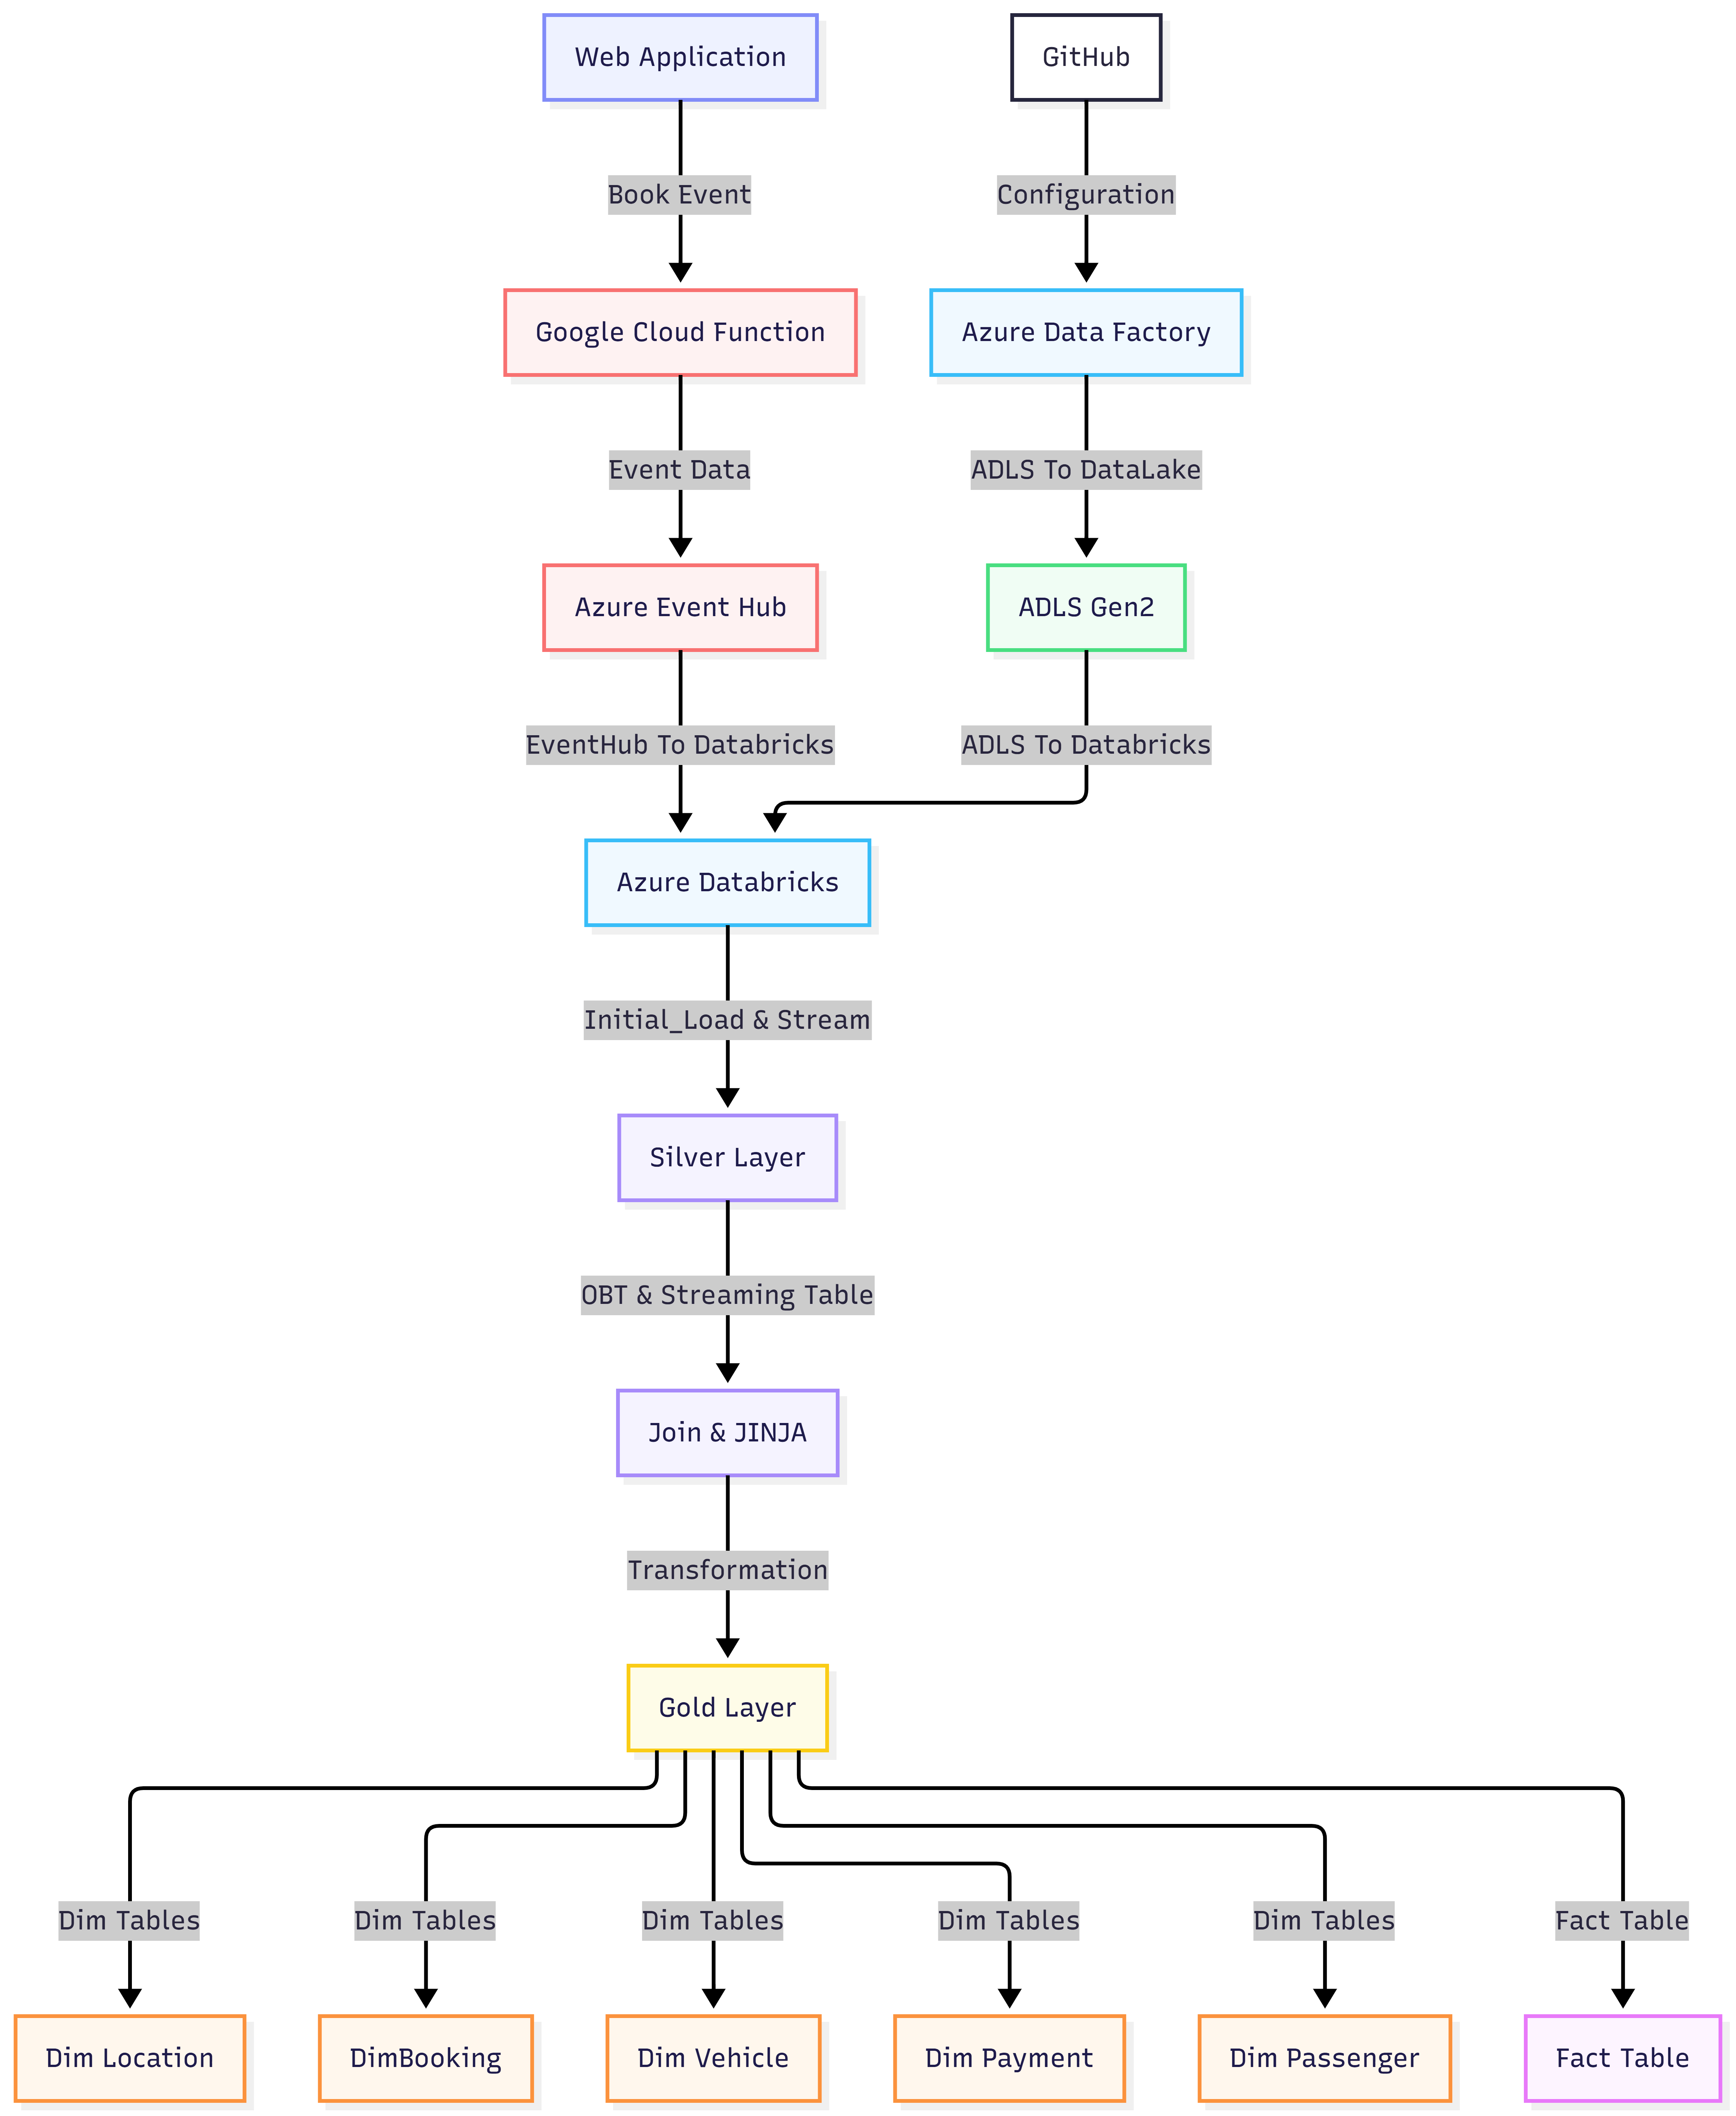

---

## ✨ Key Features

- **Real-time event streaming** - FastAPI web app publishes ride-booking events to Azure Event Hubs (Kafka-compatible) with separate Send/Listen shared access policies for producer/consumer security isolation.

- **Metadata-driven batch ingestion** - Azure Data Factory pipeline uses a JSON config file + Lookup + ForEach pattern to dynamically ingest any number of source files without pipeline modifications.

- **Medallion Architecture (Bronze → Silver → Gold)** - governed by Databricks Unity Catalog with proper catalog/schema separation.

- **Spark Declarative Pipelines (SDP)** - streaming tables, append flows, and auto CDC with automatic checkpoint management, offset tracking, and exactly-once semantics - no manual `writeStream` boilerplate.

- **Jinja2 SQL templating** - the Silver-layer OBT is built via a config-driven Jinja2 template that dynamically generates multi-table LEFT JOIN queries. Adding a new mapping table is a one-line config change with zero risk to existing logic.

- **Star Schema with SCD Type 2** - six dimension tables (five SCD-1, one SCD-2 with historical tracking via auto-generated `__start_at` / `__end_at` columns) and one streaming fact table.

---

## 🛠️ Tech Stack

| Layer | Technology | Purpose |
|-------|-----------|---------|
| **Event Generation** | Python, FastAPI, Uvicorn | Web app simulating ride bookings (producer) |
| **Streaming Platform** | Azure Event Hubs (Standard tier) | Kafka-compatible managed event ingestion |
| **Batch Orchestration** | Azure Data Factory | Parameterised, metadata-driven data movement |
| **Data Lake** | Azure Data Lake Storage Gen2 | Raw file landing zone (hierarchical namespace) |
| **Compute & Transform** | Databricks (Free Edition), PySpark | Streaming + batch transformations |
| **Pipeline Framework** | Spark Declarative Pipelines (SDP) | Declarative streaming tables, append flows, CDC |
| **SQL Generation** | Jinja2 | Metadata-driven SQL templating for OBT joins |
| **Table Format** | Delta Lake | ACID transactions, time travel, schema evolution |
| **Governance** | Unity Catalog | Three-level namespace (Catalog → Schema → Table) |

---

## 🔄 Pipeline Flow

### 1. Event Generation (Producer)
A FastAPI web app simulates ride bookings. Each booking generates a JSON event containing ride details (ride ID, passenger, driver, vehicle, locations, fares, timestamps) and publishes it to Azure Event Hubs using the `azure-eventhub` SDK authenticated via a Send shared access policy.

### 2. Batch Ingestion (ADF)
A metadata-driven ADF pipeline ingests 7 JSON files from GitHub into ADLS Gen2. A Lookup activity reads `files_array.json`, a ForEach iterates over the file list, and a parameterised Copy Activity handles each file dynamically - both source URL and sink path are driven by the config.

### 3. Bronze Layer (Raw Landing)
- **`rides_raw`** - SDP streaming table consuming Event Hub via Kafka connector. Binary values decoded to string.
- **`bulk_rides`** - historical ride records loaded once via notebook with existence guardrail.
- **6 × `map_*` tables** - static mapping/reference data loaded from ADLS via Pandas → Spark conversion.

### 4. Silver Layer (Staging + OBT)
- **`staging_rides`** - empty streaming table populated by two `append_flow` sources: bulk (one-time) + stream (continuous). JSON string normalised to structured columns via `from_json()`.
- **`silver_obt`** - One Big Table created by LEFT JOINing `staging_rides` with all 6 mapping tables. SQL query generated dynamically by a Jinja2 template driven by a Python config array. Streaming execution uses `WATERMARK` on `booking_timestamp` with a 3-minute delay threshold.

### 5. Gold Layer (Star Schema)
- **5 dimensions (SCD Type 1):** `dim_passenger`, `dim_driver`, `dim_vehicle`, `dim_booking`, `dim_payment`
- **1 dimension (SCD Type 2):** `dim_location` - tracks historical city changes with `__start_at` / `__end_at` columns, sequenced by `city_updated_at`
- **1 fact table:** `fact_rides` - all numeric/financial columns + dimension foreign keys

All Gold tables built using SDP's `create_auto_cdc_flow` API.

> ⚠️ When joining `fact_rides` to `dim_location`, always filter `WHERE __end_at IS NULL` to avoid row multiplication from historical SCD-2 records.

---

### Databricks Setup
1. Create a catalog (`Uber`) and schema (`bronze`) in Unity Catalog
2. Create an SDP ETL Pipeline (`Uber Rides Ingestion`)
3. Add the `ingest.py`, `silver.py`, `silver_obt.sql`, and `model.py` files to the Transformations folder
4. Configure the Event Hub connection string in SDP pipeline settings
5. Run the pipeline - Dry Run first, then Run Pipeline

---

## 🧠 Design Decisions

| Decision | Rationale |
|----------|-----------|
| Event Hubs over self-hosted Kafka | Zero infrastructure management; Kafka-compatible wire protocol means identical PySpark code |
| Standard tier (not Basic) | Basic tier disables Kafka protocol endpoints required by Spark connectors |
| ELT over ETL | Transformations happen in Databricks (distributed compute), not in ADF (lightweight orchestrator) |
| `append_flow` over UNION | Avoids re-reading entire historical table on every pipeline run; bulk data loaded once, stream processed incrementally |
| Jinja2 over hard-coded SQL | Separates logic (template) from data (config); adding a table = one dictionary, zero template changes |
| SCD Type 2 only for `dim_location` | Historical tracking applied only where business requires audit trail; over-engineering all dimensions adds unnecessary storage and query complexity |
| SAS tokens for ADLS access | Workaround for Databricks Free Edition (AWS-hosted); production would use Access Connector with Managed Identity |

---

## 📝 Lessons Learned

- **Debugging is the job.** Config typos, schema mismatches, returning the wrong DataFrame variable - ~60% of development time was debugging, which is realistic for production data engineering.
- **Schema changes require Full Refresh.** Altering a column type (e.g., string → timestamp) leaves stale metadata even after `DROP TABLE`. SDP's "Run Pipeline with Full Refresh" is required.
- **SCD Type 2 join filter is non-negotiable.** Forgetting `WHERE __end_at IS NULL` when joining fact to `dim_location` silently multiplies row counts - a cross-join effect that produces incorrect analytics.
- **Event Hub retention is real.** Events expire after the configured retention period (48 hours in this project). The pipeline must consume events before they expire, or they are lost from Event Hub. Delta tables in Databricks are permanent.

---

## 🔮 Future Improvements

- [ ] Automate Jinja2 rendering → SDP `.sql` file transfer via `dbutils`
- [ ] Separate SDP pipelines per Medallion layer (Bronze / Silver / Gold)
- [ ] Add SDP expectations (data quality checks) between layers
- [ ] Enable Event Hub Capture for auto-archival to ADLS as a safety net
- [ ] Implement role-playing dimension for drop-off location (reuse `dim_location`)
- [ ] Add unit tests for the Jinja2 template rendering
- [ ] Migrate from SAS tokens to Managed Identity for production deployment

---

## 📄 Licence

This project was built for educational purposes as part of a data engineering portfolio.

---

<p align="center">
  <strong>Built with</strong> Azure Event Hubs · Azure Data Factory · ADLS Gen2 · Databricks · Spark Declarative Pipelines · Jinja2 · Delta Lake · Unity Catalog
</p>